# NER Evaluation: Model Comparison

This notebook analyses the NER evaluation scores across different models,
showing only **relaxed** precision/recall/F1 metrics and filtering out runs
with API/parsing failures (`count_failed_pages > 0`), so that only correct F1 scores are shown.

---
**How to use:**
1. Set `PROMPT_LANGUAGE`, `PROMPT_MODE` and `TEMPERATURE` in the configuration
   cell below to match the evaluation data you want to analyse.

**Configuration options:**
- `PROMPT_LANGUAGE`: `"dutch"` or `"english"`
- `PROMPT_MODE`: `"zeroshot"` or `"fewshot"`
- `TEMPERATURE`: `0.0` (float — must match the value in scores.csv)

The notebook filters the `scores.csv` to only include rows matching all three
settings. If you change the config, re-run all cells to update the figures.

In [20]:
# ============================================================
# CONFIGURATION — change these to match your evaluation run
# ============================================================
PROMPT_LANGUAGE = "dutch"   # "dutch" or "english"
PROMPT_MODE = "fewshot"    # "zeroshot" or "fewshot"
TEMPERATURE = 0.0           # float — must match scores.csv (0 | 0.5 | 1.0)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

CONFIG_LABEL = f"{PROMPT_LANGUAGE} / {PROMPT_MODE} / t={TEMPERATURE}"
print(f"Configuration: {CONFIG_LABEL}")
print("Imports loaded")

# ============================================================
# FIGURE EXPORT — high-quality images for thesis use
# ============================================================
FIGURES_DIR = Path.cwd().parent / "ner" / "figures"
if not (Path.cwd().parent / "ner").exists():
    FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# safe config tag for filenames, e.g. "dutch / fewshot / t=1.0" -> "dutch_fewshot_t1.0"
CONFIG_SAFE = CONFIG_LABEL.replace(" / ", "_").replace("=", "")

def save_figure(fig, name, tag_config=True, dpi=300):
    """Save a figure as high-resolution PNG into /figures.

    PNG at 300 dpi is the best Google-Docs-friendly option: lossless (sharp text
    and thin lines, no JPEG artifacts) and accepted by Google Docs. Insert at a
    display size <= the native pixel size so Docs renders it crisply.
    tag_config=True appends the current config to the filename (for config-specific
    plots); False for plots that span all configurations.
    """
    tag = f"_{CONFIG_SAFE}" if tag_config else ""
    stem = f"{name}{tag}"
    path = FIGURES_DIR / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    shown = FIGURES_DIR.relative_to(Path.cwd().parent) if (Path.cwd().parent / "ner").exists() else FIGURES_DIR
    print(f"  -> figure saved: {shown}/{stem}.png  ({path.stat().st_size//1024} KB, {dpi} dpi)")


Configuration: dutch / fewshot / t=0.0
Imports loaded


## Progress Tracker for Configurations

Checks which model × configuration combinations have been completed by
scanning for the existence of output `.spacy` files. ✅ = run completed,
❌ = still to do.

**Models:** the 8 models used in this study.
**Configurations:** language (dutch/english) × mode (zeroshot/fewshot) ×
temperature (0.0 / 0.5 / 1.0).

In [21]:
# --- Run Tracker ---
# Scans ner-output/ for completed .spacy files and shows a completion matrix.

NER_OUTPUT = Path.cwd().parent / "ner" / "ner-output"
if not NER_OUTPUT.exists():
    NER_OUTPUT = Path.cwd() / "ner-output"

# The 8 models used in this study
MODELS = [
    "gemma4:31b",
    "deepseek-v4-pro",
    "deepseek-v4-flash",
    "mistral-large-3:675b",
    "qwen3.5:397b",
    "kimi-k2.7-code",
    "cogito-2.1:671b",
    "glm-5.1",
]

# Configurations to track
LANGUAGES = ["dutch", "english"]
MODES = ["zeroshot", "fewshot"]
TEMPERATURES = [0.0, 0.5, 1.0]

LETTER = "1816_third_letter"
SHORT = "1816"

# Build completion matrix
rows = []
for model in MODELS:
    row = {"Model": model}
    for lang in LANGUAGES:
        for mode in MODES:
            for temp in TEMPERATURES:
                spacy_path = (
                    NER_OUTPUT / model / SHORT /
                    f"{LETTER}__{model}_t{temp}_{mode}_{lang}.spacy"
                )
                col = f"{lang[:3]}/{mode[:3]}/t={temp}"
                row[col] = "✅" if spacy_path.exists() else "❌"
    rows.append(row)

tracker = pd.DataFrame(rows).set_index("Model")

# Count completed per model
tracker["✅ Completed"] = (tracker.values == "✅").sum(axis=1)
tracker["❌ Remaining"] = (tracker.values == "❌").sum(axis=1)

print(f"Scanning: {NER_OUTPUT}")
print(f"Total combos: {len(MODELS)} models × {len(LANGUAGES)} langs × {len(MODES)} modes × {len(TEMPERATURES)} temps = {len(MODELS) * len(LANGUAGES) * len(MODES) * len(TEMPERATURES)}\n")
tracker

Scanning: /home/tijn-do/hist-dutch-travelogues-nlp/ner/ner-output
Total combos: 8 models × 2 langs × 2 modes × 3 temps = 96



,dut/zer/t=0.0,dut/zer/t=0.5,dut/zer/t=1.0,dut/few/t=0.0,dut/few/t=0.5,dut/few/t=1.0,eng/zer/t=0.0,eng/zer/t=0.5,eng/zer/t=1.0,eng/few/t=0.0,eng/few/t=0.5,eng/few/t=1.0,✅ Completed,❌ Remaining
Model,,,,,,,,,,,,,,
gemma4:31b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
deepseek-v4-pro,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
deepseek-v4-flash,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
mistral-large-3:675b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
qwen3.5:397b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
kimi-k2.7-code,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
cogito-2.1:671b,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0
glm-5.1,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,✅,12,0


## Top 10 Overall Relaxed F1 Across All Configurations

Horizontal bar chart showing the 10 best overall relaxed F1 scores across
all models, languages, prompting modes, and temperatures.

  -> figure saved: ner/figures/top10_overall_relaxed_f1.png  (295 KB, 300 dpi)


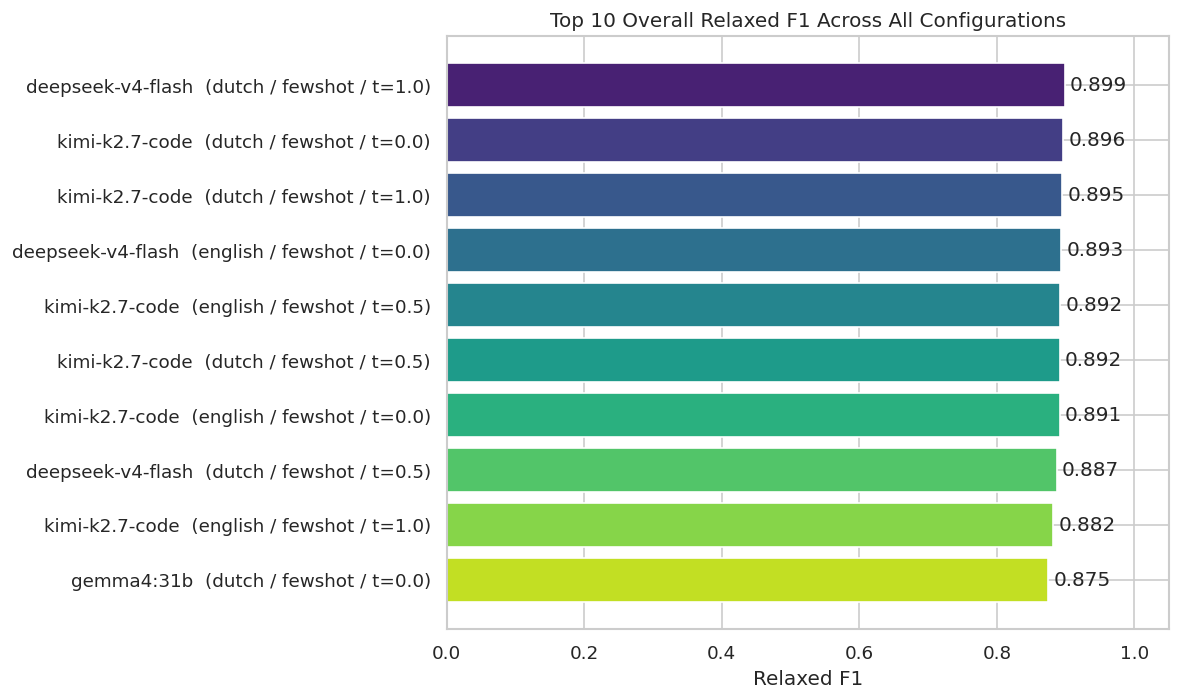


Full ranking of all model × configuration combinations:


,model,config,relaxed_p,relaxed_r,relaxed_f1
0,deepseek-v4-flash,dutch / fewshot / t=1.0,0.9118,0.8857,0.8986
1,kimi-k2.7-code,dutch / fewshot / t=0.0,0.8735,0.9206,0.8964
2,kimi-k2.7-code,dutch / fewshot / t=1.0,0.8827,0.9079,0.8951
3,deepseek-v4-flash,english / fewshot / t=0.0,0.9082,0.8794,0.8935
4,kimi-k2.7-code,english / fewshot / t=0.5,0.8921,0.8921,0.8921
...,...,...,...,...,...
91,cogito-2.1:671b,dutch / zeroshot / t=0.0,0.7220,0.5524,0.6259
92,cogito-2.1:671b,english / zeroshot / t=1.0,0.7960,0.5079,0.6202
93,cogito-2.1:671b,english / zeroshot / t=0.5,0.7111,0.5079,0.5926
94,cogito-2.1:671b,dutch / zeroshot / t=1.0,0.7308,0.4825,0.5813


In [22]:
# --- Top 10 Overall Relaxed F1 Across All Configurations ---
# Load fresh, filter failed pages, deduplicate, keep all configs
SCORES_PATH = Path.cwd().parent / "ner" / "ner-evaluation" / "scores.csv"
if not SCORES_PATH.exists():
    SCORES_PATH = Path.cwd() / "ner-evaluation" / "scores.csv"

df_top10 = pd.read_csv(SCORES_PATH)
df_top10 = df_top10[df_top10["count_failed_pages"] == 0].copy()
df_top10["datetime"] = pd.to_datetime(df_top10["datetime"])
df_top10 = df_top10.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, build a readable config label
overall_top10 = df_top10[df_top10["label"] == "OVERALL"].copy()
overall_top10["config"] = overall_top10.apply(
    lambda r: f"{r['prompt_language']} / {r['prompting_method']} / t={r['temperature']}", axis=1
)

# Build a combined label for the y-axis: model + config
overall_top10["label_display"] = overall_top10.apply(
    lambda r: f"{r['model']}  ({r['config']})", axis=1
)

# Sort by relaxed_f1 descending, take top 10
top10 = overall_top10.sort_values("relaxed_f1", ascending=False).head(10)

# Plot: horizontal bar chart, best at top
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", len(top10))
bars = ax.barh(
    top10["label_display"][::-1],   # reverse so best is at top
    top10["relaxed_f1"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Relaxed F1")
ax.set_title("Top 10 Overall Relaxed F1 Across All Configurations")
ax.set_xlim(0, 1.05)
plt.tight_layout()
save_figure(fig, 'top10_overall_relaxed_f1', tag_config=False)
plt.show()

# Also print the full ranking table
print("\nFull ranking of all model × configuration combinations:")
ranking = overall_top10.sort_values("relaxed_f1", ascending=False).reset_index(drop=True)
ranking[["model", "config", "relaxed_p", "relaxed_r", "relaxed_f1"]]

## Gold Standard Entity Counts

Number of annotated entities per label in the 1816 ground truth (Recogito JSON-LD).

In [23]:
# --- Gold Standard Entity Counts ---
# Load the Recogito JSON-LD and count entities per CIDOC-CRM label

GS_PATH = Path.cwd().parent / "ner" / "gs_annotations" / "1816.jsonld"
if not GS_PATH.exists():
    GS_PATH = Path.cwd() / "gs_annotations" / "1816.jsonld"

import json
from collections import Counter

gs_data = json.loads(GS_PATH.read_text())

label_counts = Counter()
for ann in gs_data:
    for body in ann.get("body", []):
        if body.get("purpose") == "tagging":
            # Normalise to NER label format: "E53 Place" → "E53_Place", "E52 Time-Span" → "E52_Time_Span"
            raw = body.get("value", "unknown")
            normalised = raw.replace(" ", "_").replace("-", "_")
            label_counts[normalised] += 1

# Build a DataFrame in the same order as the NER label_order
label_order = [
    "E53_Place", "E18_Physical_Thing", "E19_Physical_Object",
    "Mode_of_Transportation", "E52_Time_Span", "E20_Biological_Object",
    "F2_Expression", "E31_Document",
]
gs_df = pd.DataFrame([
    {"Label": lbl, "Count": label_counts.get(lbl, 0)}
    for lbl in label_order
])
gs_df["%"] = (gs_df["Count"] / gs_df["Count"].sum() * 100).round(1)

print(f"Total annotations: {len(gs_data)}")
print(f"Total tagged entities: {gs_df['Count'].sum()}\n")
gs_df.style.format({"Count": "{:d}", "%": "{:.1f}%"})

Total annotations: 319
Total tagged entities: 315



,Label,Count,%
0,E53_Place,108,34.3%
1,E18_Physical_Thing,62,19.7%
2,E19_Physical_Object,50,15.9%
3,Mode_of_Transportation,30,9.5%
4,E52_Time_Span,29,9.2%
5,E20_Biological_Object,17,5.4%
6,F2_Expression,14,4.4%
7,E31_Document,5,1.6%


## 1. Load and filter data

- Exclude runs where `count_failed_pages > 0` (API errors, parsing failures)
- Keep only rows matching the configured `PROMPT_LANGUAGE` and `PROMPT_MODE`
- For models with multiple valid runs, keep only the most recent one

In [24]:
SCORES_PATH = Path.cwd().parent / "ner" / "ner-evaluation" / "scores.csv"
if not SCORES_PATH.exists():
    SCORES_PATH = Path.cwd() / "ner-evaluation" / "scores.csv"

df = pd.read_csv(SCORES_PATH)
print(f"Loaded {len(df)} rows from {SCORES_PATH.name}")
print(f"Columns: {list(df.columns)}")

Loaded 945 rows from scores.csv
Columns: ['source_text', 'model', 'temperature', 'prompting_method', 'prompt_language', 'pages_processed', 'duration_seconds', 'inference_type', 'count_failed_pages', 'datetime', 'label', 'strict_p', 'strict_r', 'strict_f1', 'relaxed_p', 'relaxed_r', 'relaxed_f1', 'count_tp', 'count_fp', 'count_fn']


In [25]:
# --- Filter by configured language, mode and temperature ---
n_before = len(df)
df = df[
    (df["prompt_language"] == PROMPT_LANGUAGE) &
    (df["prompting_method"] == PROMPT_MODE) &
    (df["temperature"] == TEMPERATURE)
].copy()
print(f"Filtered to {CONFIG_LABEL}: {len(df)} rows "
      f"({n_before - len(df)} rows removed)")

# --- Filter out runs with failed pages ---
n_before = len(df)
df = df[df["count_failed_pages"] == 0].copy()
n_removed = n_before - len(df)
print(f"Removed {n_removed} rows with count_failed_pages > 0")
print(f"Remaining: {len(df)} rows")

# --- For models with multiple valid runs, keep the most recent ---
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").groupby(
    ["model", "label"],
    dropna=False
).last().reset_index()
print(f"After deduplication: {len(df)} rows")

# --- Summary of included runs ---
summary = df[df["label"] == "OVERALL"][[
    "model", "prompting_method", "prompt_language", "temperature",
    "duration_seconds", "datetime", "count_failed_pages"
]].sort_values("model").reset_index(drop=True)
summary

Filtered to dutch / fewshot / t=0.0: 90 rows (855 rows removed)
Removed 0 rows with count_failed_pages > 0
Remaining: 90 rows
After deduplication: 72 rows


,model,prompting_method,prompt_language,temperature,duration_seconds,datetime,count_failed_pages
0,cogito-2.1:671b,fewshot,dutch,0.0,234.1,2026-06-16 08:22:43,0
1,deepseek-v4-flash,fewshot,dutch,0.0,1099.8,2026-06-16 00:43:06,0
2,deepseek-v4-pro,fewshot,dutch,0.0,1388.1,2026-06-15 22:55:51,0
3,gemma4:31b,fewshot,dutch,0.0,164.4,2026-06-15 22:16:07,0
4,glm-5.1,fewshot,dutch,0.0,3326.5,2026-06-16 09:35:55,0
5,kimi-k2.7-code,fewshot,dutch,0.0,1751.6,2026-06-16 05:50:57,0
6,mistral-large-3:675b,fewshot,dutch,0.0,250.7,2026-06-16 02:14:34,0
7,qwen3.5:397b,fewshot,dutch,0.0,2095.8,2026-06-16 03:08:59,0


## 2. Overall Relaxed F1 by Model

Horizontal bar chart showing each model's overall relaxed F1 score.

  -> figure saved: ner/figures/overall_relaxed_f1_by_model_dutch_fewshot_t0.0.png  (169 KB, 300 dpi)


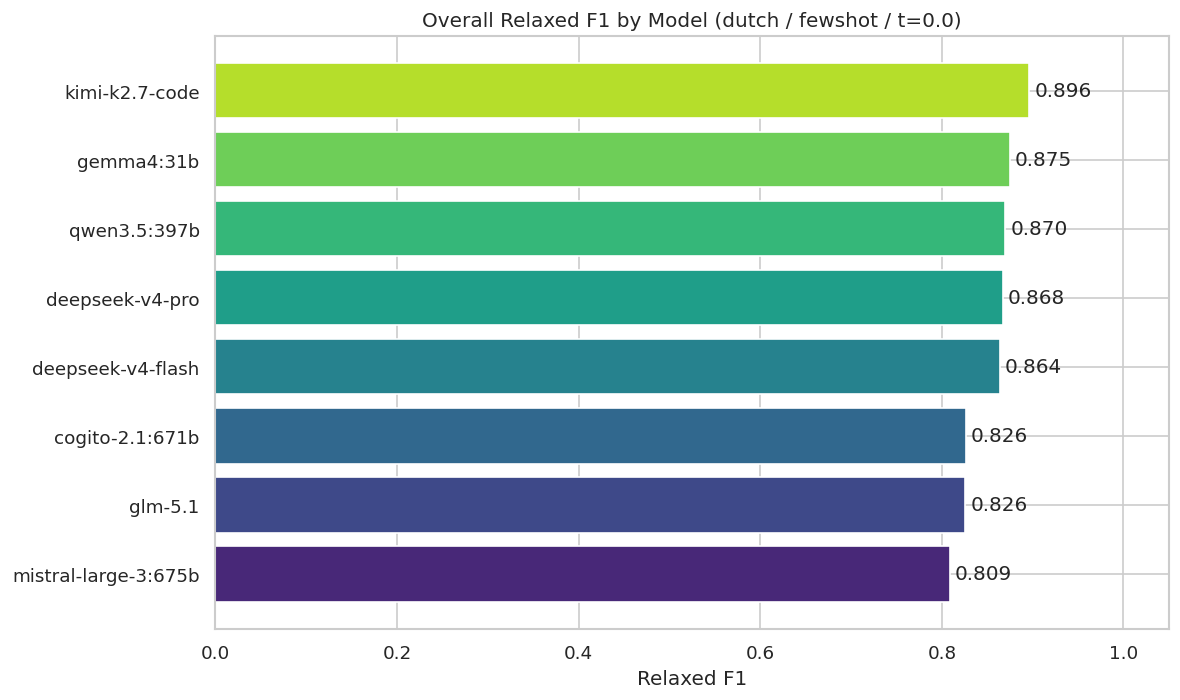

In [26]:
overall = df[df["label"] == "OVERALL"].copy().sort_values("relaxed_f1")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    overall["model"],
    overall["relaxed_f1"],
    color=sns.color_palette("viridis", len(overall)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Relaxed F1")
ax.set_title(f"Overall Relaxed F1 by Model ({CONFIG_LABEL})")
ax.set_xlim(0, 1.05)
plt.tight_layout()
save_figure(fig, 'overall_relaxed_f1_by_model', tag_config=True)
plt.show()

## 3. Per-Label F1 Heatmap

Models as rows, entity labels as columns, colour = relaxed F1.

  -> figure saved: ner/figures/per_label_relaxed_f1_heatmap_dutch_fewshot_t0.0.png  (450 KB, 300 dpi)


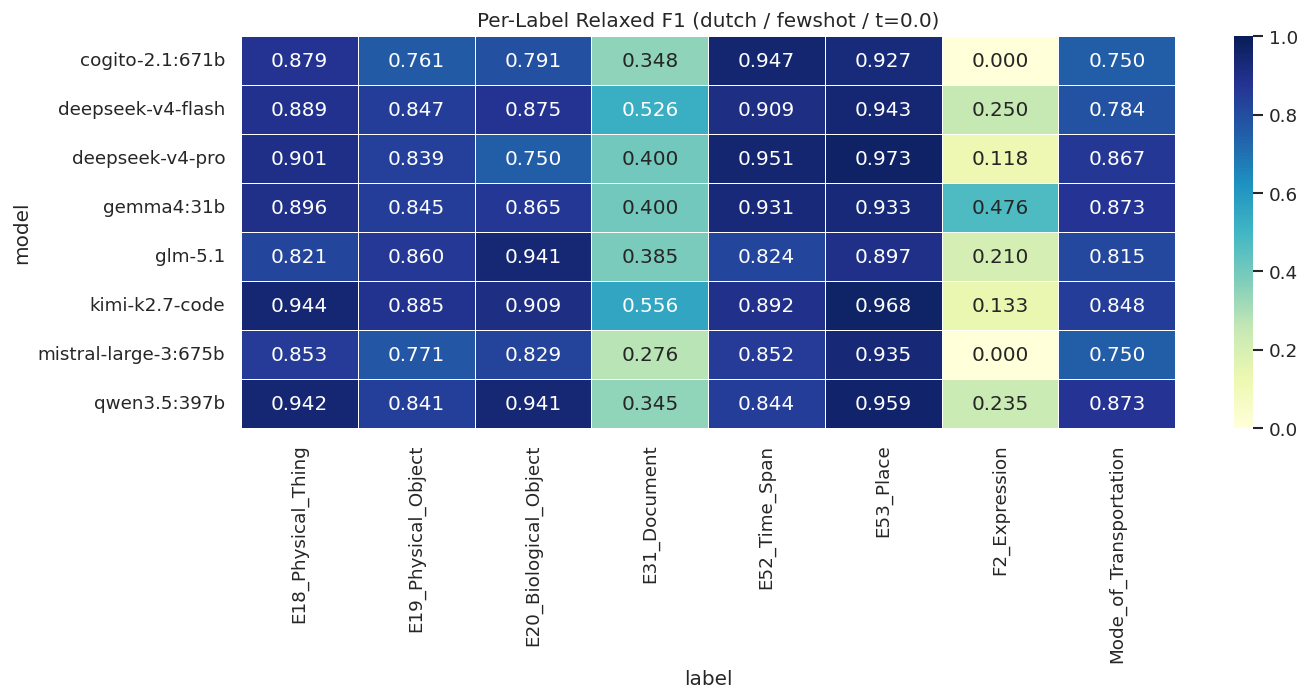

In [27]:
per_label = df[df["label"] != "OVERALL"].copy()
pivot = per_label.pivot_table(
    index="model",
    columns="label",
    values="relaxed_f1",
    aggfunc="last",
)
# Order columns: E labels first, then F2, then Mode_of_Transportation
label_order = [
    "E18_Physical_Thing", "E19_Physical_Object", "E20_Biological_Object",
    "E31_Document", "E52_Time_Span", "E53_Place",
    "F2_Expression", "Mode_of_Transportation",
]
pivot = pivot[[c for c in label_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title(f"Per-Label Relaxed F1 ({CONFIG_LABEL})")
plt.tight_layout()
save_figure(fig, 'per_label_relaxed_f1_heatmap', tag_config=True)
plt.show()

## 4. Per-Label Relaxed Precision & Recall

One subplot per entity label, showing precision and recall side by side.

  -> figure saved: ner/figures/per_label_precision_vs_recall_dutch_fewshot_t0.0.png  (553 KB, 300 dpi)


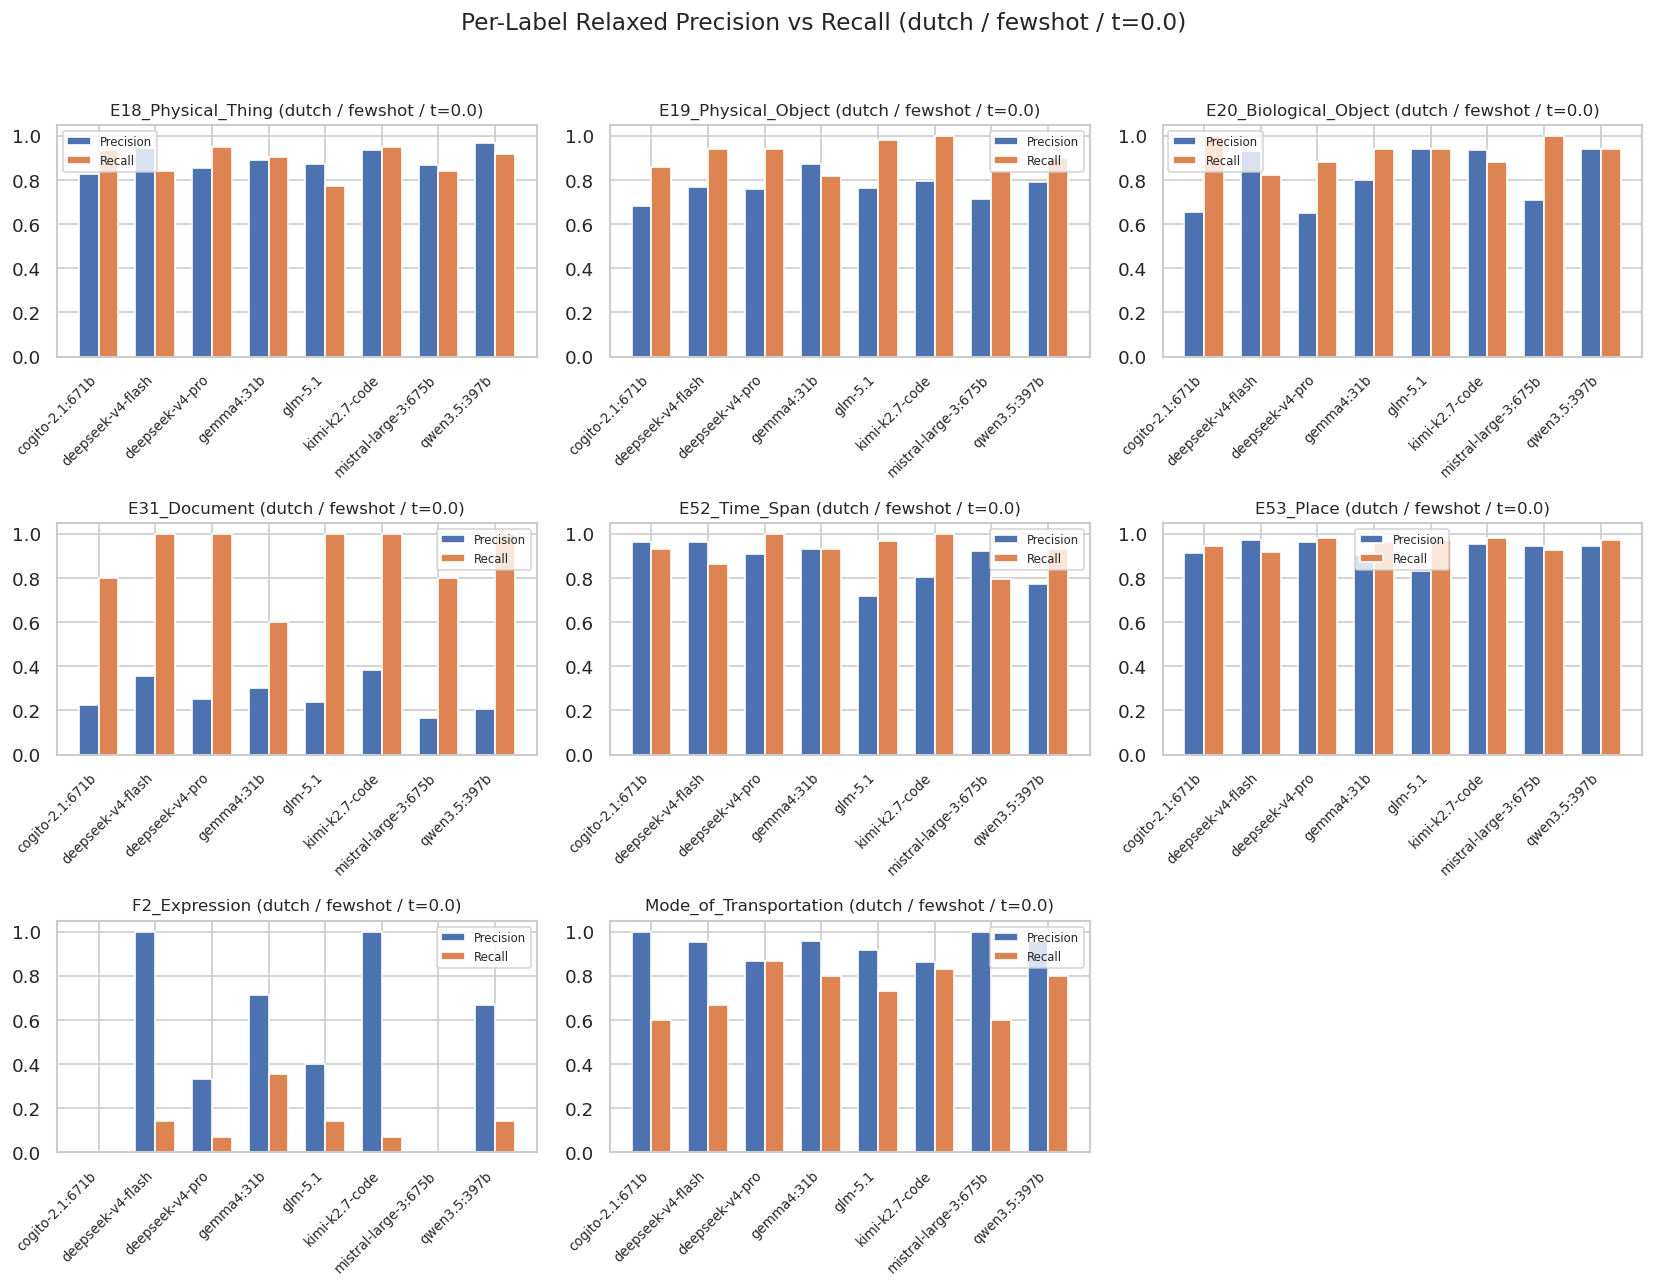

In [28]:
labels = [c for c in label_order if c in per_label["label"].unique()]
n_labels = len(labels)
n_cols = 3
n_rows = int(np.ceil(n_labels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    ax = axes[i]
    subset = per_label[per_label["label"] == lbl].sort_values("model")
    x = np.arange(len(subset))
    width = 0.35
    ax.bar(x - width/2, subset["relaxed_p"], width, label="Precision", color="#4C72B0")
    ax.bar(x + width/2, subset["relaxed_r"], width, label="Recall", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(subset["model"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{lbl} ({CONFIG_LABEL})", fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Per-Label Relaxed Precision vs Recall ({CONFIG_LABEL})", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'per_label_precision_vs_recall', tag_config=True)
plt.show()

## 5a. Inference Time Comparison

How long each model took to process all pages.

  -> figure saved: ner/figures/inference_time_per_model_dutch_fewshot_t0.0.png  (240 KB, 300 dpi)


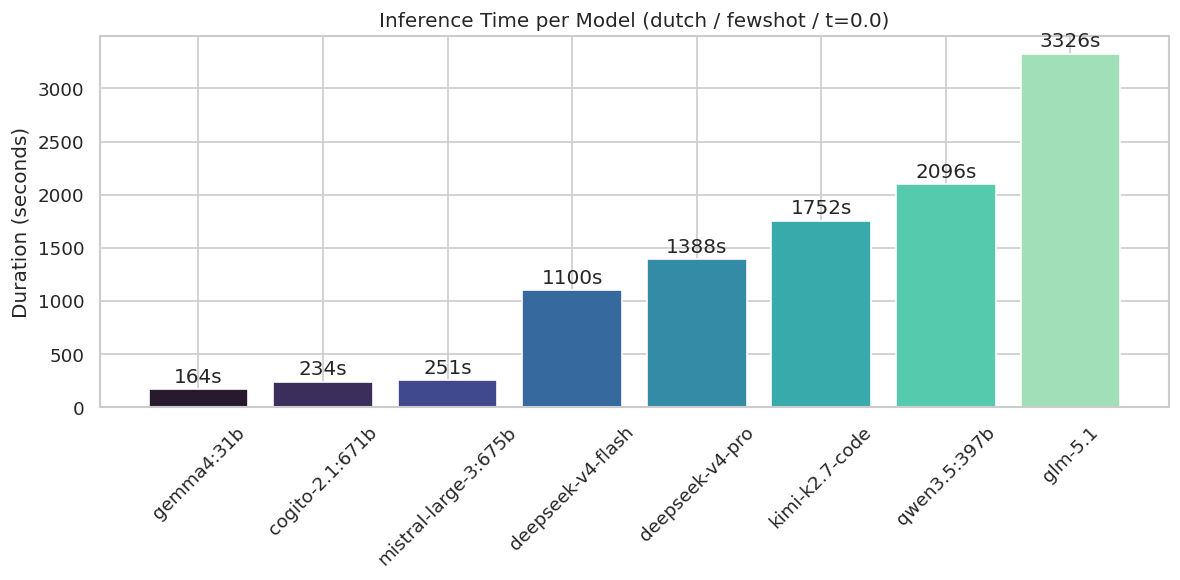

In [29]:
timing = overall.sort_values("duration_seconds")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    timing["model"],
    timing["duration_seconds"],
    color=sns.color_palette("mako", len(timing)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.0fs", padding=2)
ax.set_ylabel("Duration (seconds)")
ax.set_title(f"Inference Time per Model ({CONFIG_LABEL})")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save_figure(fig, 'inference_time_per_model', tag_config=True)
plt.show()

## 5b. Inference Time vs Relaxed F1

Scatter plot showing the trade-off between inference speed and performance.
Models in the top-left quadrant are both fast and accurate.

  -> figure saved: ner/figures/inference_time_vs_f1_dutch_fewshot_t0.0.png  (161 KB, 300 dpi)


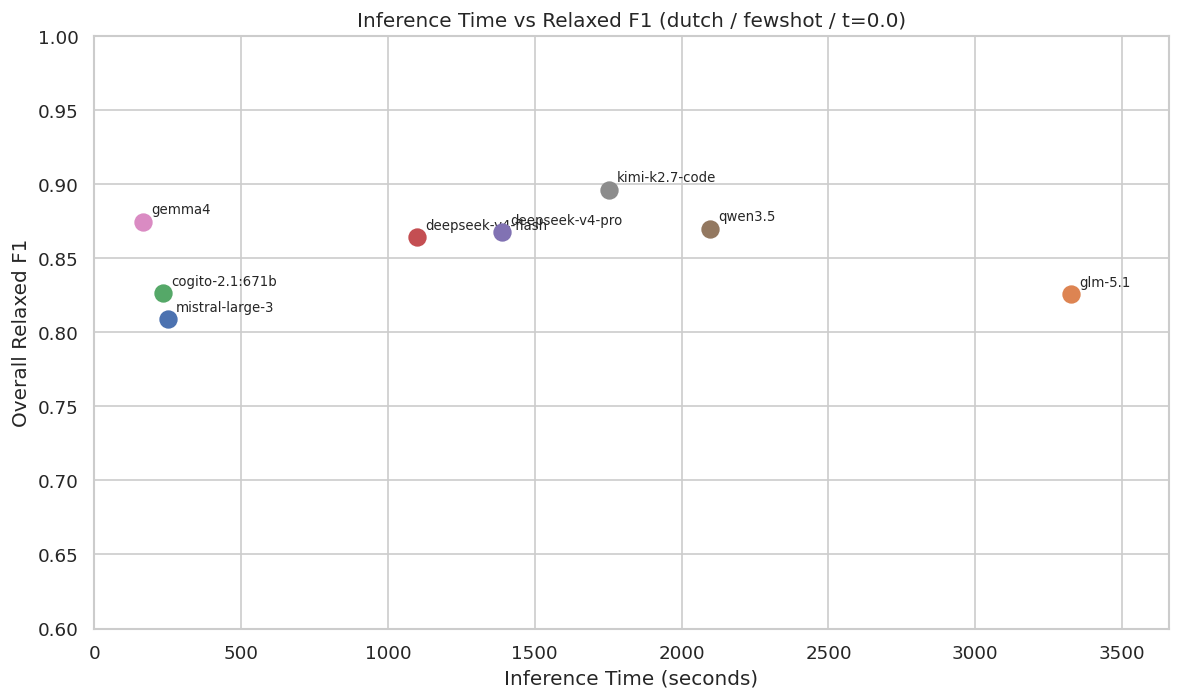

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter: time vs F1, labelled by model
for _, row in overall.iterrows():
    ax.scatter(row["duration_seconds"], row["relaxed_f1"], s=100, zorder=5)
    ax.annotate(
        row["model"].replace(":31b", "").replace(":397b", "").replace(":675b", ""),
        (row["duration_seconds"], row["relaxed_f1"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )

ax.set_xlabel("Inference Time (seconds)")
ax.set_ylabel("Overall Relaxed F1")
ax.set_title(f"Inference Time vs Relaxed F1 ({CONFIG_LABEL})")
ax.set_xlim(0, overall["duration_seconds"].max() * 1.1)
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
save_figure(fig, 'inference_time_vs_f1', tag_config=True)
plt.show()

## 5c. Expected Inference Time for the Full Transcription of 1816

Expected inference time for the full ~240-page 1816 transcription, based on the
**average inference time across all completed configurations** (all languages ×
modes × temperatures) per model on the 10-page test set.

  -> figure saved: ner/figures/expected_inference_time_full_transcription.png  (220 KB, 300 dpi)


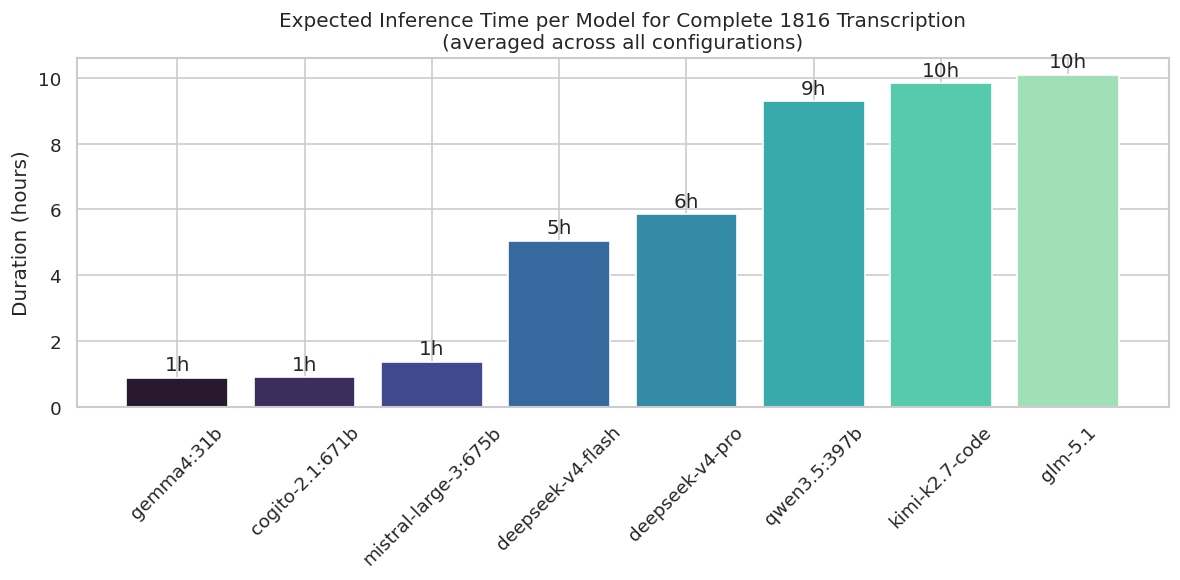

Average inference time per model (10 pages):


,model,duration_seconds
3,gemma4:31b,147.30s
0,cogito-2.1:671b,148.24s
6,mistral-large-3:675b,227.62s
1,deepseek-v4-flash,837.77s
2,deepseek-v4-pro,970.28s
7,qwen3.5:397b,1540.30s
5,kimi-k2.7-code,1631.68s
4,glm-5.1,1674.87s


In [31]:
# --- Load all runs, average inference time per model across all configs ---
df_all = pd.read_csv(SCORES_PATH)
df_all = df_all[df_all["count_failed_pages"] == 0].copy()
df_all["datetime"] = pd.to_datetime(df_all["datetime"])
df_all = df_all.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, group by model and average duration
overall_all = df_all[df_all["label"] == "OVERALL"].copy()
avg_duration = (
    overall_all.groupby("model")["duration_seconds"]
    .mean()
    .reset_index()
    .sort_values("duration_seconds")
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    avg_duration["model"],
    avg_duration["duration_seconds"] / 60 / 10 / 60 * 217,  # seconds → min → ÷10 pages → hours × 217 pages
    color=sns.color_palette("mako", len(avg_duration)),
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.0fh", padding=2)
ax.set_ylabel("Duration (hours)")
ax.set_title("Expected Inference Time per Model for Complete 1816 Transcription\n(averaged across all configurations)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save_figure(fig, 'expected_inference_time_full_transcription', tag_config=False)
plt.show()

# Show the per-model averages used
print("Average inference time per model (10 pages):")
avg_duration.style.format({"duration_seconds": "{:.2f}s"})

## 6. Summary Table (Colour-Coded)

Pivot table with relaxed F1 per model per label, colour-coded for quick scanning.

  -> figure saved: ner/figures/summary_relaxed_f1_heatmap_dutch_fewshot_t0.0.png  (565 KB, 300 dpi)


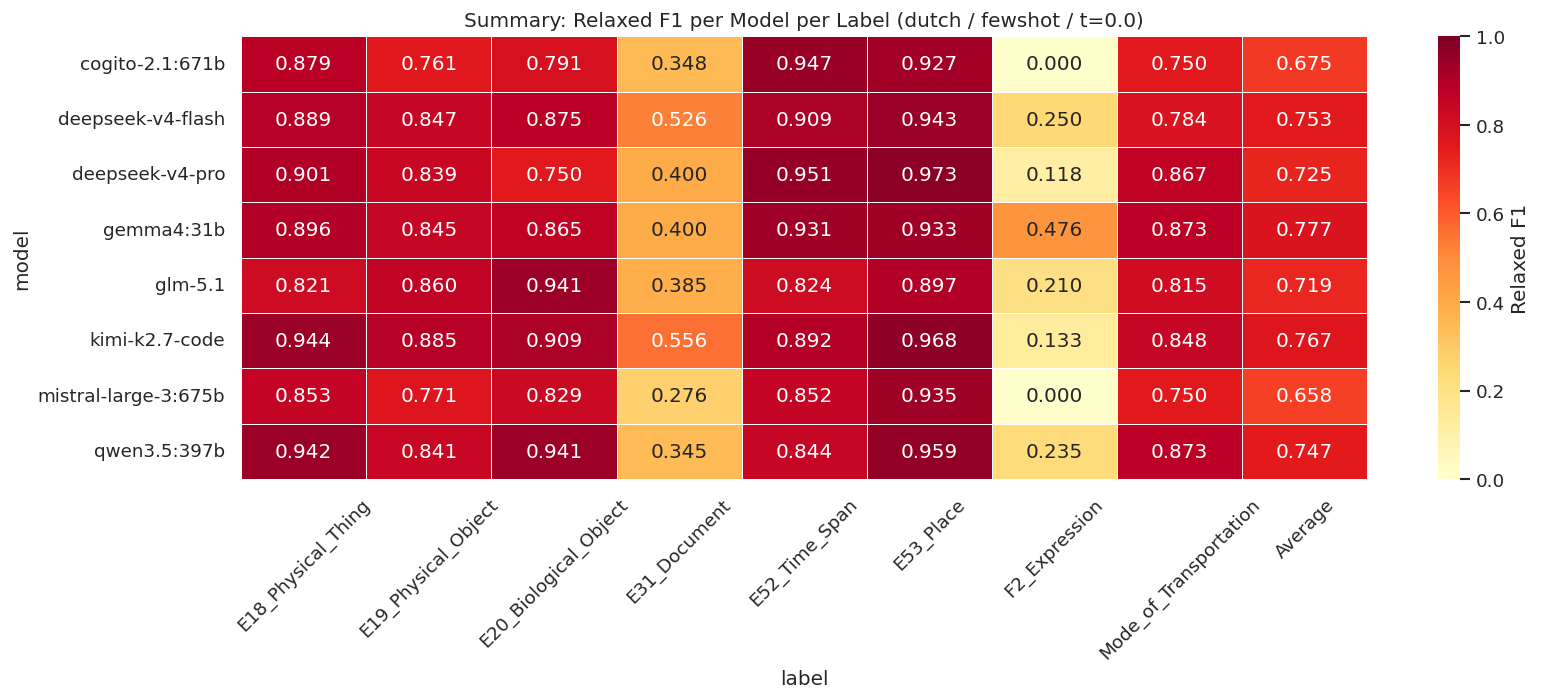

In [ ]:
# Add an "Average" column
pivot["Average"] = pivot.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relaxed F1"})
ax.set_title(f"Summary: Relaxed F1 per Model per Label ({CONFIG_LABEL})", fontsize=12)
plt.tight_layout()
save_figure(fig, 'summary_relaxed_f1_heatmap', tag_config=True)
plt.show()

## 6b. Entity Counts per Label

Gold standard entity counts alongside the total number of predicted entities (TP+FP) and
gold entities (TP+FN) per label, summed across all models in the current configuration.
This gives a sense of how many entities each label has in the ground truth and whether
models tend to over- or under-predict each label.

In [ ]:
# --- Gold Standard Entity Counts per Label ---
GS_PATH = Path.cwd().parent / "ner" / "gs_annotations" / "1816.jsonld"
if not GS_PATH.exists():
    GS_PATH = Path.cwd() / "gs_annotations" / "1816.jsonld"

import json
from collections import Counter

gs_data = json.loads(GS_PATH.read_text())
label_counts = Counter()
for ann in gs_data:
    for body in ann.get("body", []):
        if body.get("purpose") == "tagging":
            raw = body.get("value", "unknown")
            normalised = raw.replace(" ", "_").replace("-", "_")
            label_counts[normalised] += 1

label_order = [
    "E53_Place", "E18_Physical_Thing", "E19_Physical_Object",
    "Mode_of_Transportation", "E52_Time_Span", "E20_Biological_Object",
    "F2_Expression", "E31_Document",
]
gs_df = pd.DataFrame([
    {"Label": lbl, "Count": label_counts.get(lbl, 0)}
    for lbl in label_order
])
gs_df["%"] = (gs_df["Count"] / gs_df["Count"].sum() * 100).round(1)

print(f"Total annotations: {len(gs_data)}")
print(f"Total tagged entities: {gs_df['Count'].sum()}\n")
gs_df.style.format({"Count": "{:d}", "%": "{:.1f}%"})

## 7. Best Model per Label

Quick table showing which model achieves the highest relaxed F1 for each entity label.

In [33]:
best = per_label.loc[
    per_label.groupby("label")["relaxed_f1"].idxmax(),
    ["label", "model", "relaxed_p", "relaxed_r", "relaxed_f1"]
].set_index("label").sort_index()
best.columns = ["Best Model", "Precision", "Recall", "F1"]
best

,Best Model,Precision,Recall,F1
label,,,,
E18_Physical_Thing,kimi-k2.7-code,0.9365,0.9516,0.9440
E19_Physical_Object,kimi-k2.7-code,0.7937,1.0000,0.8850
E20_Biological_Object,glm-5.1,0.9412,0.9412,0.9412
E31_Document,kimi-k2.7-code,0.3846,1.0000,0.5556
E52_Time_Span,deepseek-v4-pro,0.9062,1.0000,0.9508
E53_Place,deepseek-v4-pro,0.9636,0.9815,0.9725
F2_Expression,gemma4:31b,0.7143,0.3571,0.4762
Mode_of_Transportation,gemma4:31b,0.9600,0.8000,0.8727


## 8. Overall F1 per Configuration

Heatmap showing each model's **overall relaxed F1** across all available
configurations (language × prompting mode × temperature). Models as rows,
configurations as columns, which makes it easy to spot which settings work best
for each model.

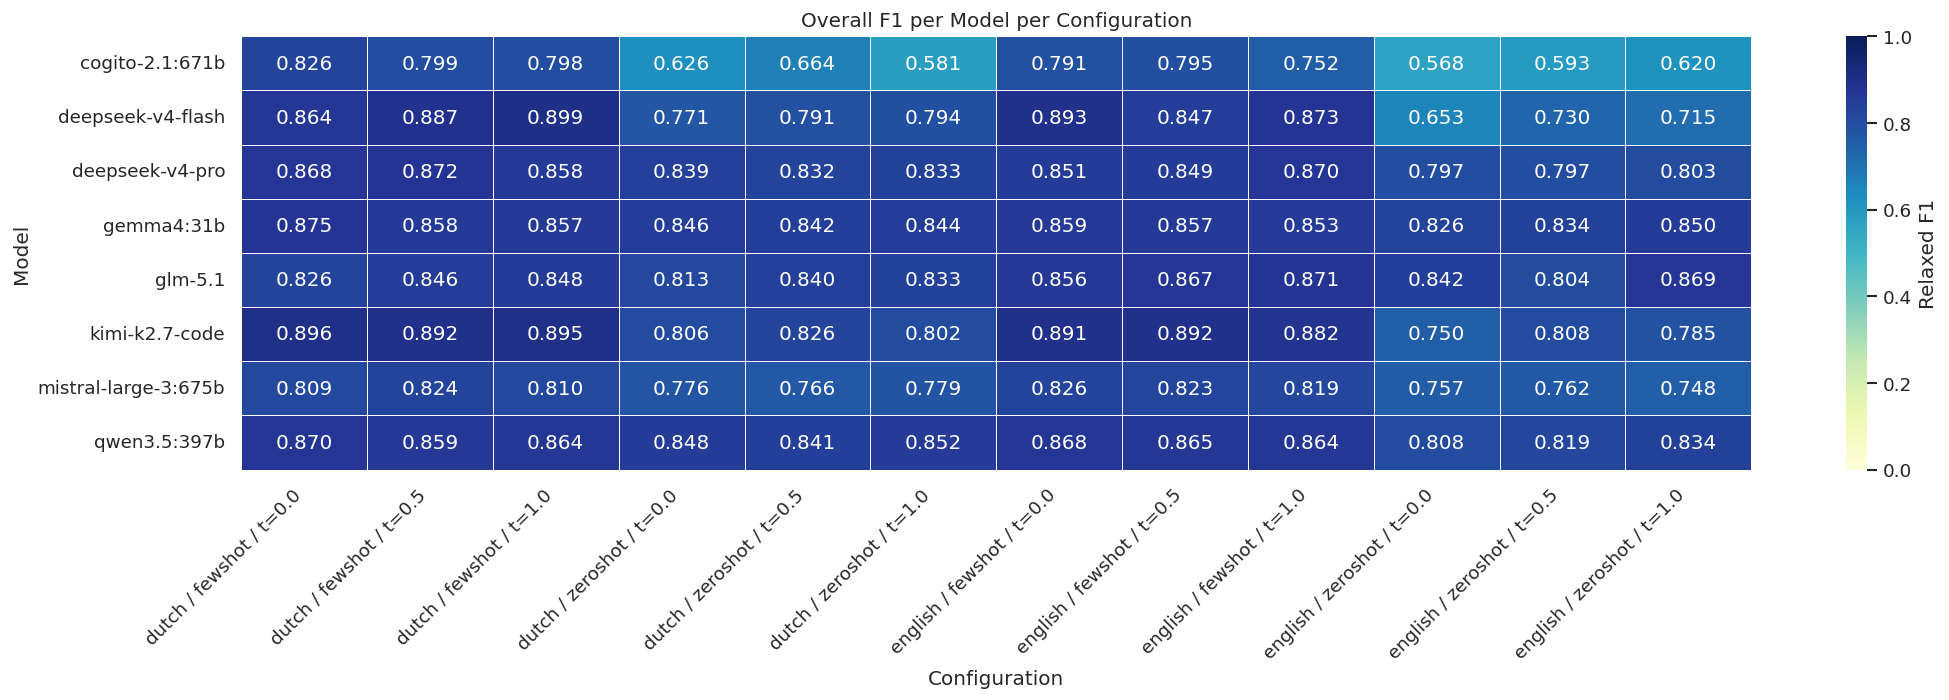

Configs shown: 12, Models: 8


In [34]:
# --- Overall F1 across all configs ---
# Load fresh, filter failed pages + deduplicate, keep all configs
df_full = pd.read_csv(SCORES_PATH)
df_full = df_full[df_full["count_failed_pages"] == 0].copy()
df_full["datetime"] = pd.to_datetime(df_full["datetime"])
df_full = df_full.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

# Only OVERALL rows, build config label
overall_full = df_full[df_full["label"] == "OVERALL"].copy()
overall_full["config"] = overall_full.apply(
    lambda r: f"{r['prompt_language']} / {r['prompting_method']} / t={r['temperature']}", axis=1
)

# Pivot: models × configs, values = relaxed_f1
pivot_cfg = overall_full.pivot_table(
    index="model", columns="config", values="relaxed_f1", aggfunc="last",
)

# Sort config columns logically: language first, then mode, then temperature
col_order = sorted(pivot_cfg.columns)
pivot_cfg = pivot_cfg[col_order]

fig, ax = plt.subplots(figsize=(max(8, len(col_order) * 1.5), 6))
sns.heatmap(pivot_cfg, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relaxed F1"})
plt.xticks(rotation=45, ha='right')
ax.set_title("Overall F1 per Model per Configuration", fontsize=12)
ax.set_ylabel("Model")
ax.set_xlabel("Configuration")
plt.tight_layout()
plt.show()

print(f"Configs shown: {len(col_order)}, Models: {len(pivot_cfg)}")

## Dutch vs English: matched-configuration comparison
For every `(model × prompting_mode × temperature)` triple that has **both** a Dutch and an English run,
pair the two and compare overall performance. Positive **delta = Dutch wins**; negative = English wins.
This isolates the prompt-language effect from model/mode/temperature differences (exact configuration match).

,model,prompting_method,temperature,relaxed_f1_dutch,relaxed_f1_english,relaxed_delta_dutch_minus_english,relaxed_winner,strict_f1_dutch,strict_f1_english,strict_delta_dutch_minus_english,strict_winner
0,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
1,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
2,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
3,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
4,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
5,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
6,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
7,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
8,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f
9,.3f,.3f,.3f,.3f,.3f,+.3f,.3f,.3f,.3f,+.3f,.3f


Matched configurations (both languages present): 48
  Relaxed F1 -> Dutch wins: 35 | English wins: 13 | Ties: 0
  Mean relaxed delta (Dutch - English): +0.0158
  Mean strict  delta (Dutch - English): +0.0124
  => On average DUTCH prompting performs better on this corpus (relaxed F1).
  -> figure saved: ner/figures/dutch_vs_english_delta.png  (584 KB, 300 dpi)


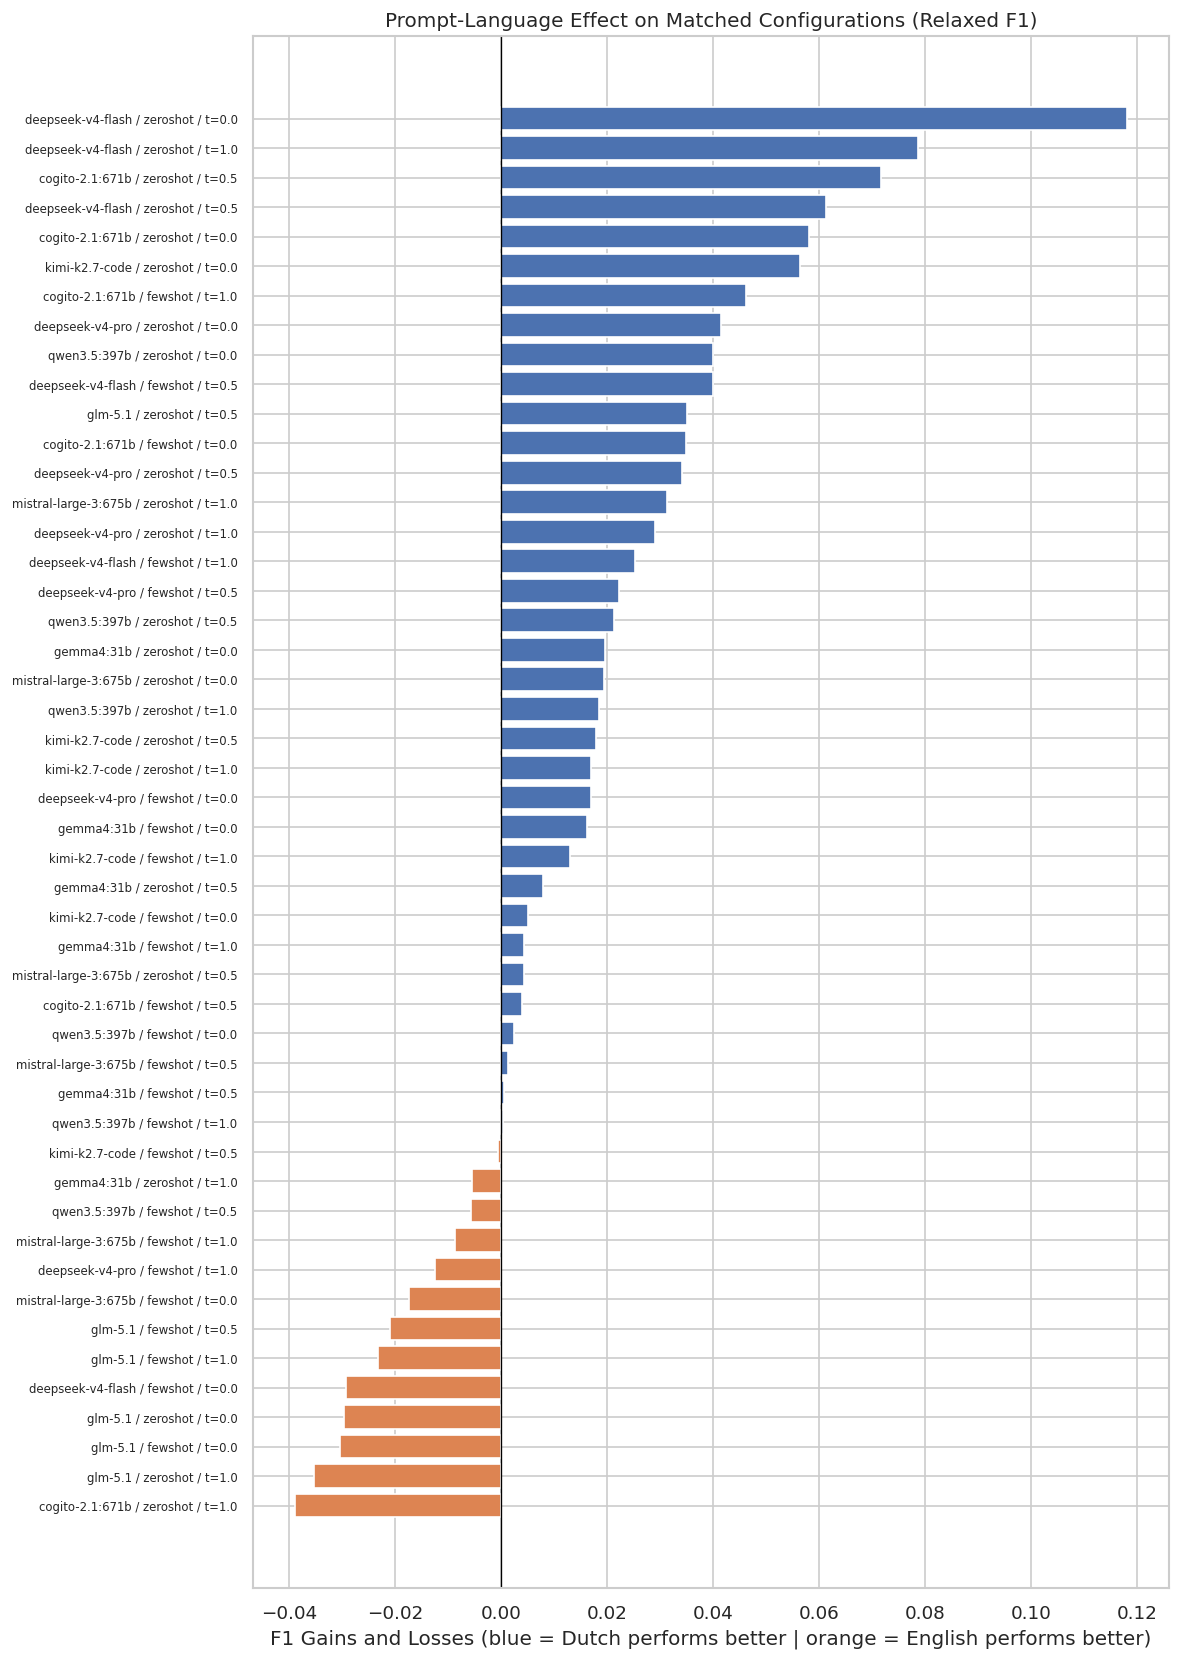

In [35]:
# --- Dutch vs English: matched-configuration language comparison ---
# Pair runs that differ ONLY in prompt_language (same model, mode, temperature),
# then compare overall relaxed/strict F1 to see which language wins.
SCORES_PATH = Path.cwd().parent / "ner" / "ner-evaluation" / "scores.csv"
if not SCORES_PATH.exists():
    SCORES_PATH = Path.cwd() / "ner-evaluation" / "scores.csv"

df_lang = pd.read_csv(SCORES_PATH)
df_lang = df_lang[df_lang["count_failed_pages"] == 0].copy()
df_lang["datetime"] = pd.to_datetime(df_lang["datetime"])
df_lang = df_lang.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()

overall_lang = df_lang[df_lang["label"] == "OVERALL"].copy()

# Put Dutch and English side-by-side per matched (model, mode, temperature)
matched = overall_lang.pivot_table(
    index=["model", "prompting_method", "temperature"],
    columns="prompt_language",
    values=["relaxed_f1", "strict_f1"],
    aggfunc="last",
)
matched.columns = [f"{metric}_{lang}" for metric, lang in matched.columns]
matched = matched.reset_index()

# Keep only configs present in BOTH languages
matched = matched.dropna(subset=["relaxed_f1_dutch", "relaxed_f1_english"]).copy()
matched["relaxed_delta_dutch_minus_english"] = matched["relaxed_f1_dutch"] - matched["relaxed_f1_english"]
matched["strict_delta_dutch_minus_english"]  = matched["strict_f1_dutch"]  - matched["strict_f1_english"]

def _winner(d):
    if d > 0:   return "dutch"
    if d < 0:   return "english"
    return "tie"

matched["relaxed_winner"] = matched["relaxed_delta_dutch_minus_english"].apply(_winner)
matched["strict_winner"]  = matched["strict_delta_dutch_minus_english"].apply(_winner)

# --- Metric table ---
cols = [
    "model", "prompting_method", "temperature",
    "relaxed_f1_dutch", "relaxed_f1_english", "relaxed_delta_dutch_minus_english", "relaxed_winner",
    "strict_f1_dutch", "strict_f1_english", "strict_delta_dutch_minus_english", "strict_winner",
]
table = matched[cols].sort_values(["model", "prompting_method", "temperature"])
fmt = {c: ("+.3f" if "delta" in c else ".3f") for c in cols}
display(table.style.format(fmt).map(
    lambda v: "background-color: #dceafd" if isinstance(v, str) and v == "dutch"
    else ("background-color: #fde2d4" if isinstance(v, str) and v == "english" else ""),
    subset=["relaxed_winner", "strict_winner"]
))

# --- Summary metric ---
n = len(matched)
dw_r = (matched["relaxed_winner"] == "dutch").sum()
ew_r = (matched["relaxed_winner"] == "english").sum()
tw_r = (matched["relaxed_winner"] == "tie").sum()
mean_rel = matched["relaxed_delta_dutch_minus_english"].mean()
mean_str = matched["strict_delta_dutch_minus_english"].mean()
print("=" * 60)
print(f"Matched configurations (both languages present): {n}")
print(f"  Relaxed F1 -> Dutch wins: {dw_r} | English wins: {ew_r} | Ties: {tw_r}")
print(f"  Mean relaxed delta (Dutch - English): {mean_rel:+.4f}")
print(f"  Mean strict  delta (Dutch - English): {mean_str:+.4f}")
if mean_rel > 0:
    print("  => On average DUTCH prompting performs better on this corpus (relaxed F1).")
elif mean_rel < 0:
    print("  => On average ENGLISH prompting performs better on this corpus (relaxed F1).")
else:
    print("  => No average difference between the two languages.")
print("=" * 60)

# --- Diverging bar chart of the language delta (one bar per matched config) ---
plot = matched.sort_values("relaxed_delta_dutch_minus_english").copy()
plot["config"] = plot.apply(
    lambda r: f"{r['model']} / {r['prompting_method']} / t={r['temperature']}", axis=1
)
fig, ax = plt.subplots(figsize=(10, min(max(6, len(plot) * 0.30), 14)))
colors = np.where(plot["relaxed_delta_dutch_minus_english"] >= 0, "#4C72B0", "#DD8452")
ax.barh(plot["config"], plot["relaxed_delta_dutch_minus_english"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("F1 Gains and Losses (blue = Dutch performs better | orange = English performs better)")
ax.set_title("Prompt-Language Effect on Matched Configurations (Relaxed F1)")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
save_figure(fig, "dutch_vs_english_delta", tag_config=False)
plt.show()

## Temperature effect: exact configuration matches (3 options)
For every `(model × prompting_mode × prompt_language)` that has **all three** temperatures (0.0, 0.5, 1.0),
compare overall relaxed F1 across temperatures. A 3-option comparison has no single delta, so instead we
report, per matched config: F1 at each temperature, the **best** temperature, and the **spread** (max − min).
Across all matches we tally which temperature wins most often and the mean F1 per temperature.

,model,prompting_method,prompt_language,f1_t0.0,f1_t0.5,f1_t1.0,best_temp,spread_max_minus_min,std_across_temps
0,cogito-2.1:671b,fewshot,dutch,.3f,.3f,.3f,f1_t0.0,.4f,.4f
1,cogito-2.1:671b,fewshot,english,.3f,.3f,.3f,f1_t0.5,.4f,.4f
2,cogito-2.1:671b,zeroshot,dutch,.3f,.3f,.3f,f1_t0.5,.4f,.4f
3,cogito-2.1:671b,zeroshot,english,.3f,.3f,.3f,f1_t1.0,.4f,.4f
4,deepseek-v4-flash,fewshot,dutch,.3f,.3f,.3f,f1_t1.0,.4f,.4f
5,deepseek-v4-flash,fewshot,english,.3f,.3f,.3f,f1_t0.0,.4f,.4f
6,deepseek-v4-flash,zeroshot,dutch,.3f,.3f,.3f,f1_t1.0,.4f,.4f
7,deepseek-v4-flash,zeroshot,english,.3f,.3f,.3f,f1_t0.5,.4f,.4f
8,deepseek-v4-pro,fewshot,dutch,.3f,.3f,.3f,f1_t0.5,.4f,.4f
9,deepseek-v4-pro,fewshot,english,.3f,.3f,.3f,f1_t1.0,.4f,.4f


Matched configurations (all 3 temperatures present): 32
  t=0.0 is best in 10 of 32 configs  (mean relaxed F1 = 0.8124, std = 0.0755)
  t=0.5 is best in 10 of 32 configs  (mean relaxed F1 = 0.8182, std = 0.0630)
  t=1.0 is best in 12 of 32 configs  (mean relaxed F1 = 0.8174, std = 0.0718)
  Mean spread (max - min across temps): 0.0254
  Mean std across temps:                 0.0132
  => Highest mean F1 on average: f1_t0.5
  -> figure saved: ner/figures/temperature_effect.png  (154 KB, 300 dpi)


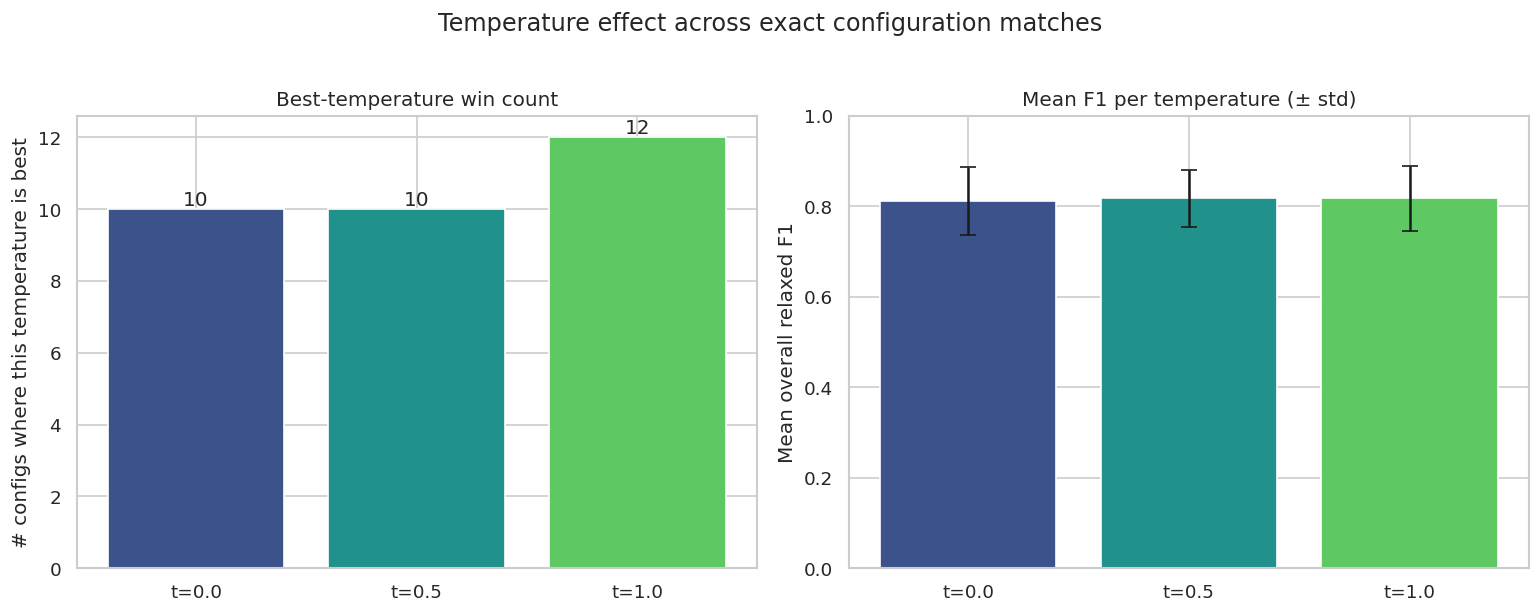

In [36]:
# --- Temperature comparison (3 options) on exact configuration matches ---
# For each (model x prompting_mode x prompt_language) that has ALL three
# temperatures, compare overall relaxed F1 across t in {0.0, 0.5, 1.0}.
# A 3-option comparison: no single delta -> best temperature + spread per config,
# a winner tally, and mean F1 per temperature across all matches.
TEMPS = [0.0, 0.5, 1.0]

df_t = pd.read_csv(SCORES_PATH)
df_t = df_t[df_t["count_failed_pages"] == 0].copy()
df_t["datetime"] = pd.to_datetime(df_t["datetime"])
df_t = df_t.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()
ov_t = df_t[df_t["label"] == "OVERALL"].copy()

# relaxed F1 across the three temperatures, per matched (model, mode, language)
wide = ov_t.pivot_table(
    index=["model", "prompting_method", "prompt_language"],
    columns="temperature", values="relaxed_f1", aggfunc="last",
)
wide.columns = [f"f1_t{c}" for c in wide.columns]
needed = [f"f1_t{t}" for t in TEMPS]
wide = wide.dropna(subset=[c for c in needed if c in wide.columns]).reset_index()

vals = wide[needed].to_numpy()
wide["best_temp"] = [needed[int(np.argmax(row))] for row in vals]
wide["spread_max_minus_min"] = vals.max(axis=1) - vals.min(axis=1)
wide["std_across_temps"] = wide[needed].std(axis=1)

# --- Metric table ---
disp_cols = ["model", "prompting_method", "prompt_language"] + needed + ["best_temp", "spread_max_minus_min", "std_across_temps"]
fmt_t = {c: ".3f" for c in needed}
fmt_t.update({"spread_max_minus_min": ".4f", "std_across_temps": ".4f"})
display(wide[disp_cols].sort_values(["model", "prompting_method", "prompt_language"]).style.format(fmt_t))

# --- Summary metric ---
n = len(wide)
print("=" * 64)
print(f"Matched configurations (all 3 temperatures present): {n}")
for t in TEMPS:
    col = f"f1_t{t}"
    cnt = int((wide["best_temp"] == col).sum())
    print(f"  t={t} is best in {cnt} of {n} configs  (mean relaxed F1 = {wide[col].mean():.4f}, std = {wide[col].std():.4f})")
print(f"  Mean spread (max - min across temps): {wide['spread_max_minus_min'].mean():.4f}")
print(f"  Mean std across temps:                 {wide['std_across_temps'].mean():.4f}")
best_col = max(needed, key=lambda c: wide[c].mean())
print(f"  => Highest mean F1 on average: {best_col}")
print("=" * 64)

# --- Figure: win counts per temperature + mean F1 per temperature ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pal = sns.color_palette("viridis", len(TEMPS))
labels = [f"t={t}" for t in TEMPS]

wcnt = [int((wide["best_temp"] == f"f1_t{t}").sum()) for t in TEMPS]
axes[0].bar(labels, wcnt, color=pal, edgecolor="white")
for i, c in enumerate(wcnt):
    axes[0].text(i, c, str(c), ha="center", va="bottom")
axes[0].set_ylabel("# configs where this temperature is best")
axes[0].set_title("Best-temperature win count")

means = [wide[f"f1_t{t}"].mean() for t in TEMPS]
stds  = [wide[f"f1_t{t}"].std() for t in TEMPS]
axes[1].bar(labels, means, yerr=stds, color=pal, edgecolor="white", capsize=5)
axes[1].set_ylabel("Mean overall relaxed F1")
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Mean F1 per temperature (± std)")
fig.suptitle("Temperature effect across exact configuration matches", y=1.02)
plt.tight_layout()
save_figure(fig, "temperature_effect", tag_config=False)
plt.show()

## Temperature effect: per-model delta table

For each model, the **delta** shows whether a specific temperature helps or hurts relative to that model's average across all temperatures (controlling for mode and language). 

**Delta = F1 at this temperature − mean F1 across all three temperatures for this model**

- Positive (🟢) = this temperature performs *above* the model's baseline
- Negative (🔴) = this temperature performs *below* the model's baseline

The table averages over all configurations (fewshot/zeroshot × Dutch/English) so the delta reflects the pure temperature effect per model.

Raw relaxed F1 per model per temperature
(averaged over fewshot/zeroshot × Dutch/English)
  -> figure saved: ner/figures/temperature_raw_f1_heatmap.png  (235 KB, 300 dpi)


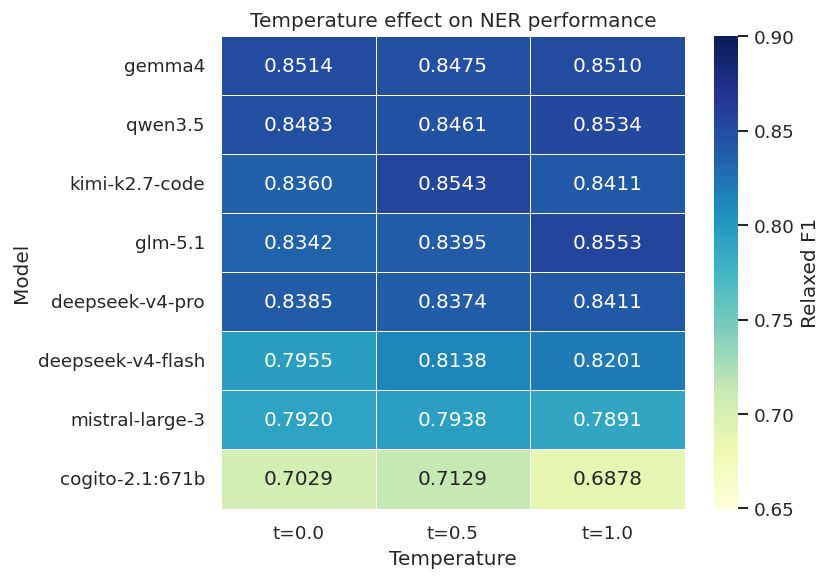


Numeric values:


,t=0.0,t=0.5,t=1.0
gemma4,0.8514,0.8475,0.8510
qwen3.5,0.8483,0.8462,0.8534
kimi-k2.7-code,0.8360,0.8543,0.8411
glm-5.1,0.8342,0.8394,0.8553
deepseek-v4-pro,0.8385,0.8374,0.8411
deepseek-v4-flash,0.7955,0.8138,0.8201
mistral-large-3,0.7920,0.7938,0.7891
cogito-2.1:671b,0.7029,0.7129,0.6878


In [37]:
# --- Temperature effect: raw F1 per model per temperature (heatmap) ---
# Shows the actual relaxed F1 values at each temperature, averaged over
# all configurations (fewshot/zeroshot × Dutch/English).
# If temperature has no effect, the three columns should look nearly identical.

df_t3 = pd.read_csv(SCORES_PATH)
df_t3 = df_t3[df_t3["count_failed_pages"] == 0].copy()
df_t3["datetime"] = pd.to_datetime(df_t3["datetime"])
df_t3 = df_t3.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()
ov_t3 = df_t3[df_t3["label"] == "OVERALL"].copy()

# Per model: average F1 at each temperature (over all modes and languages)
raw_pivot = ov_t3.pivot_table(
    index="model", columns="temperature", values="relaxed_f1", aggfunc="mean"
)
raw_pivot.columns = [f"t={c}" for c in raw_pivot.columns]

# Sort by average F1 descending
raw_pivot["avg"] = raw_pivot.mean(axis=1)
raw_pivot = raw_pivot.sort_values("avg", ascending=False).drop(columns="avg")

# Shorten model names for display
raw_pivot.index = [m.replace(":31b", "").replace(":397b", "").replace(":675b", "") for m in raw_pivot.index]

print("=" * 60)
print("Raw relaxed F1 per model per temperature")
print("(averaged over fewshot/zeroshot × Dutch/English)")
print("=" * 60)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(raw_pivot, annot=True, fmt=".4f", cmap="YlGnBu",
            vmin=0.65, vmax=0.90, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Relaxed F1"})
ax.set_title("Temperature effect on NER performance", fontsize=12)
ax.set_ylabel("Model")
ax.set_xlabel("Temperature")
plt.tight_layout()
save_figure(fig, "temperature_raw_f1_heatmap", tag_config=False)
plt.show()

# Also print the numeric table for reference
print("\nNumeric values:")
display(raw_pivot.round(4))

## Fewshot vs Zeroshot: mean deviation
For every `(model × prompt_language × temperature)` present in **both** modes, compute the fewshot−zeroshot
relaxed-F1 delta and report the **mean deviation** (headline), plus a per-config table and a diverging bar chart.

,model,prompt_language,temperature,f1_fewshot,f1_zeroshot,delta_fewshot_minus_zeroshot
29,glm-5.1,english,1.000000,.3f,.3f,+.4f
23,gemma4:31b,english,1.000000,.3f,.3f,+.4f
25,glm-5.1,dutch,0.500000,.3f,.3f,+.4f
44,qwen3.5:397b,dutch,1.000000,.3f,.3f,+.4f
20,gemma4:31b,dutch,1.000000,.3f,.3f,+.4f
24,glm-5.1,dutch,0.000000,.3f,.3f,+.4f
27,glm-5.1,english,0.000000,.3f,.3f,+.4f
26,glm-5.1,dutch,1.000000,.3f,.3f,+.4f
19,gemma4:31b,dutch,0.500000,.3f,.3f,+.4f
43,qwen3.5:397b,dutch,0.500000,.3f,.3f,+.4f


Matched configurations (both modes present): 48
  Fewshot better: 48 | Zeroshot better: 0 | Ties: 0
  MEAN DEVIATION (fewshot - zeroshot, relaxed F1): +0.0729
  => On average FEWSHOT prompting performs better.
  -> figure saved: ner/figures/fewshot_vs_zeroshot_delta.png  (531 KB, 300 dpi)


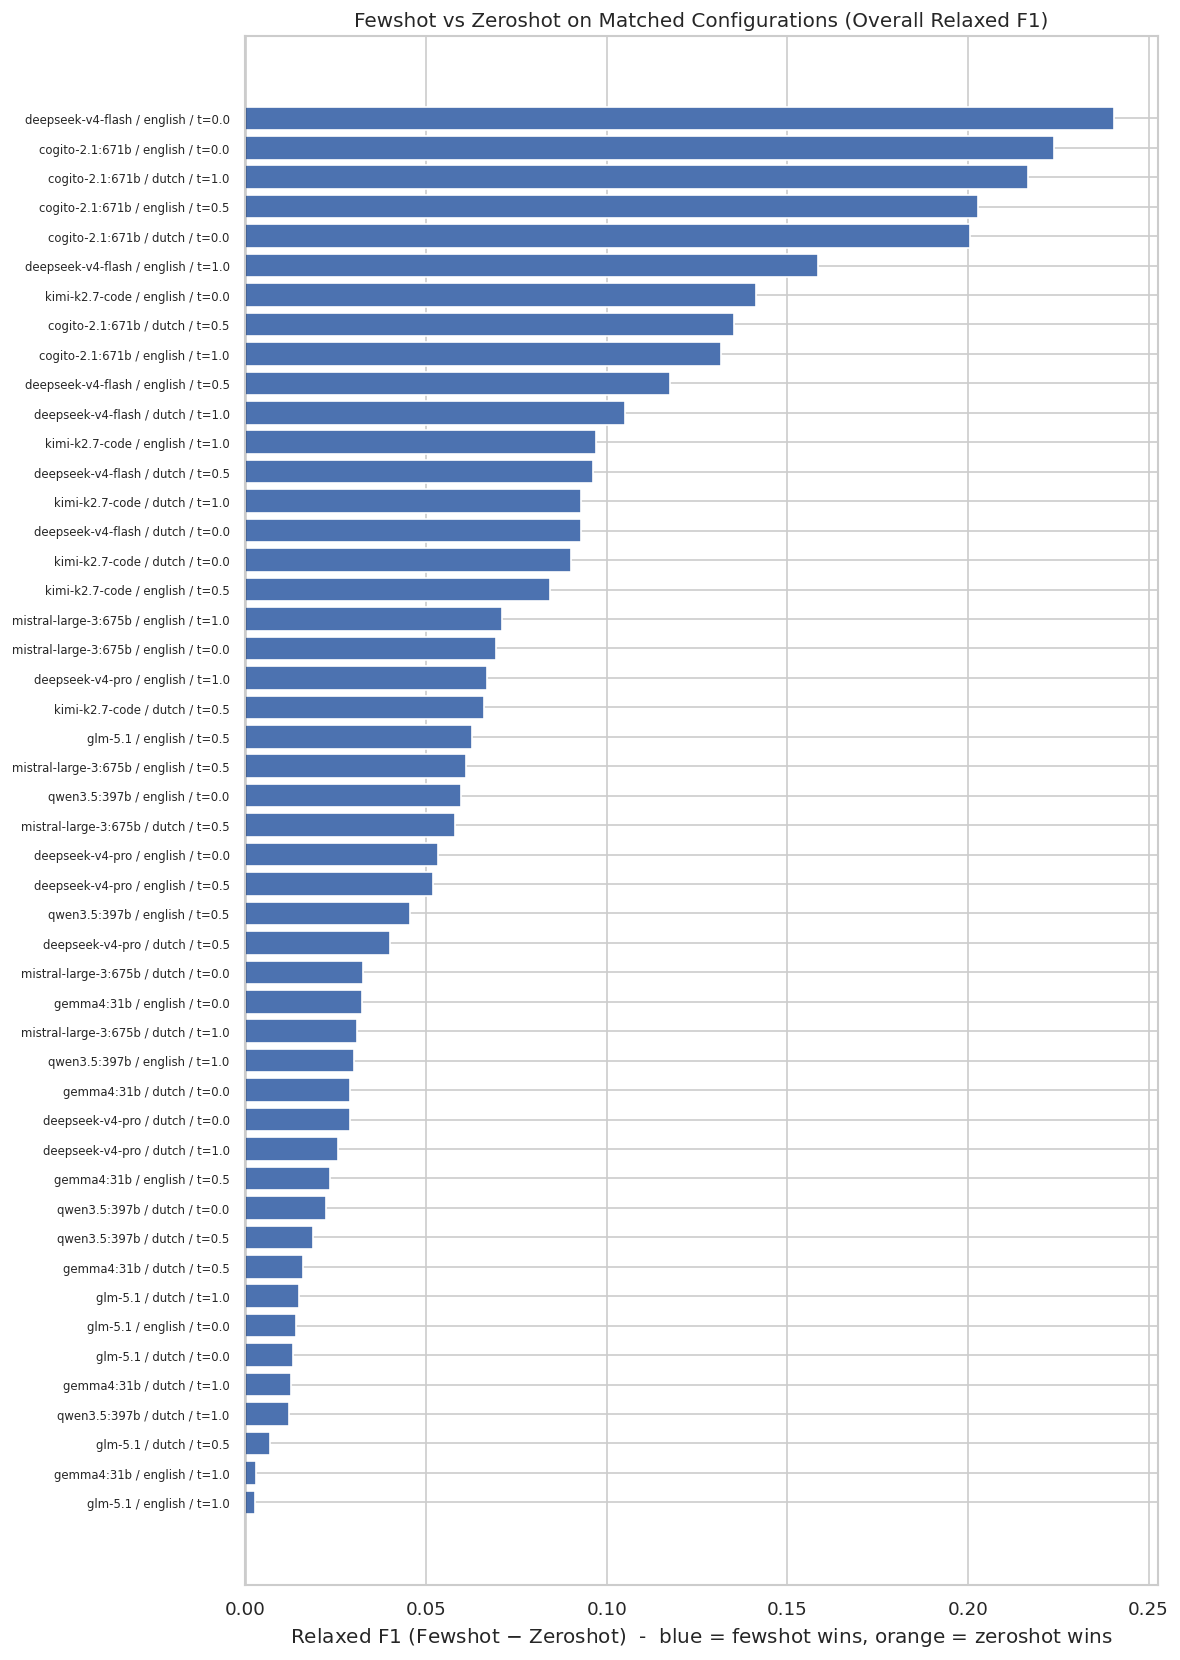

In [38]:
# --- Fewshot vs Zeroshot: mean deviation on exact configuration matches ---
# For each (model x prompt_language x temperature) present in BOTH modes, compute
# the fewshot-minus-zeroshot relaxed-F1 delta and report the MEAN DEVIATION.
df_m = pd.read_csv(SCORES_PATH)
df_m = df_m[df_m["count_failed_pages"] == 0].copy()
df_m["datetime"] = pd.to_datetime(df_m["datetime"])
df_m = df_m.sort_values("datetime").groupby(
    ["model", "label", "prompt_language", "prompting_method", "temperature"],
    dropna=False
).last().reset_index()
ov_m = df_m[df_m["label"] == "OVERALL"].copy()

mp = ov_m.pivot_table(
    index=["model", "prompt_language", "temperature"],
    columns="prompting_method", values="relaxed_f1", aggfunc="last",
)
mp.columns = [f"f1_{c}" for c in mp.columns]
have = [c for c in ["f1_fewshot", "f1_zeroshot"] if c in mp.columns]
mp = mp.reset_index().dropna(subset=have).copy()
mp["delta_fewshot_minus_zeroshot"] = mp["f1_fewshot"] - mp["f1_zeroshot"]

# --- Per-config delta table ---
disp_m = mp[["model", "prompt_language", "temperature", "f1_fewshot", "f1_zeroshot", "delta_fewshot_minus_zeroshot"]].sort_values("delta_fewshot_minus_zeroshot")
display(disp_m.style.format({"f1_fewshot": ".3f", "f1_zeroshot": ".3f", "delta_fewshot_minus_zeroshot": "+.4f"}))

# --- Mean deviation (headline) ---
mean_dev = mp["delta_fewshot_minus_zeroshot"].mean()
n = len(mp)
fw = int((mp["delta_fewshot_minus_zeroshot"] > 0).sum())
zw = int((mp["delta_fewshot_minus_zeroshot"] < 0).sum())
tw = int((mp["delta_fewshot_minus_zeroshot"] == 0).sum())
print("=" * 64)
print(f"Matched configurations (both modes present): {n}")
print(f"  Fewshot better: {fw} | Zeroshot better: {zw} | Ties: {tw}")
print(f"  MEAN DEVIATION (fewshot - zeroshot, relaxed F1): {mean_dev:+.4f}")
if mean_dev > 0:
    print("  => On average FEWSHOT prompting performs better.")
elif mean_dev < 0:
    print("  => On average ZEROSHOT prompting performs better.")
else:
    print("  => No average difference.")
print("=" * 64)

# --- Diverging bar of per-config deltas ---
plot_m = mp.sort_values("delta_fewshot_minus_zeroshot").copy()
plot_m["config"] = plot_m.apply(lambda r: f"{r['model']} / {r['prompt_language']} / t={r['temperature']}", axis=1)
fig, ax = plt.subplots(figsize=(10, min(max(6, len(plot_m) * 0.30), 14)))
colors = np.where(plot_m["delta_fewshot_minus_zeroshot"] >= 0, "#4C72B0", "#DD8452")
ax.barh(plot_m["config"], plot_m["delta_fewshot_minus_zeroshot"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Relaxed F1 (Fewshot $-$ Zeroshot)  -  blue = fewshot wins, orange = zeroshot wins")
ax.set_title("Fewshot vs Zeroshot on Matched Configurations (Overall Relaxed F1)")
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
save_figure(fig, "fewshot_vs_zeroshot_delta", tag_config=False)
plt.show()